In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Asif117204/knn_project/master/Iris.csv"

df = pd.read_csv(url)

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from mlxtend.plotting import plot_decision_regions

In [5]:
print(df.shape)

print(df.columns)

print(df.isnull().sum())

(150, 6)
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [6]:
df = df.dropna()

In [7]:
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

In [8]:
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


In [9]:
X = df.drop('Species', axis=1)

y = df['Species']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'linear'],
    'degree': [2, 3]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    refit=True,
    verbose=1,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3],
                         'gamma': [1, 0.1, 0.01], 'kernel': ['rbf', 'linear']},
             verbose=1)

In [13]:
print(grid.best_params_)

best_model = grid.best_estimator_

print(best_model)

{'C': 1, 'degree': 2, 'gamma': 1, 'kernel': 'linear'}
SVC(C=1, degree=2, gamma=1, kernel='linear', probability=True)


In [14]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr'
)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("AUC Score:", auc)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC Score: 1.0


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



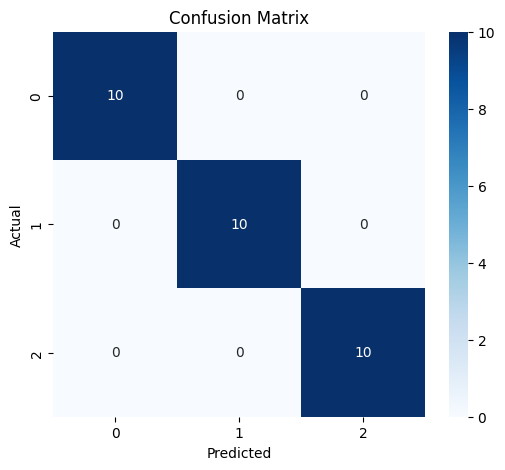

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

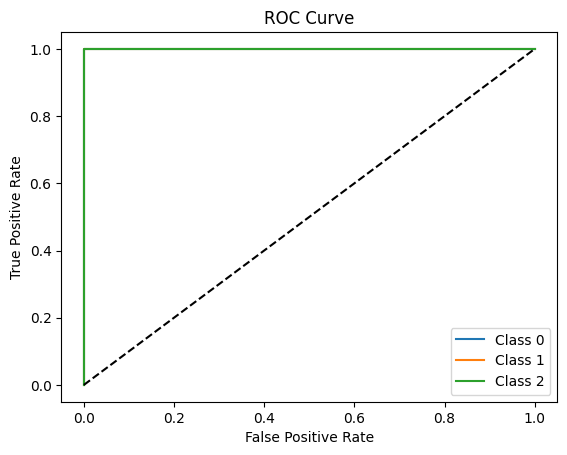

In [18]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2]
)

fpr = dict()

tpr = dict()

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i}'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [19]:
sample_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': np.max(y_prob, axis=1)
})

print(sample_results.head(10))

   Actual  Predicted  Probability
0       0          0     0.974397
1       2          2     0.620943
2       1          1     0.879144
3       1          1     0.908832
4       0          0     0.980435
5       1          1     0.846542
6       0          0     0.990079
7       0          0     0.948140
8       2          2     0.891690
9       1          1     0.845727


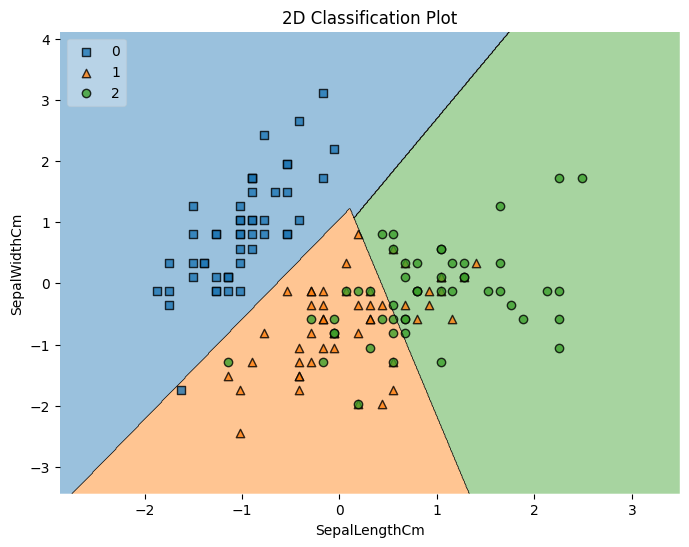

In [20]:
X_plot = X.iloc[:, :2]

y_plot = y.values.astype(int)

X_plot_scaled = scaler.fit_transform(X_plot)

svm_2d = SVC(kernel='linear')

svm_2d.fit(X_plot_scaled, y_plot)

plt.figure(figsize=(8,6))

plot_decision_regions(
    X_plot_scaled,
    y_plot,
    clf=svm_2d,
    legend=2
)

plt.title("2D Classification Plot")

plt.xlabel(X.columns[0])

plt.ylabel(X.columns[1])

plt.show()